In [ ]:
from google.colab import files
files.upload()

Saving filtered_variants_p_1e-08.csv to filtered_variants_p_1e-08.csv
Saving test_dataset_1e-8.txt to test_dataset_1e-8.txt
Saving train_val_dataset_1e-8.txt to train_val_dataset_1e-8.txt


{'filtered_variants_p_1e-08.csv': b'SNP,CHR,BP,P,A1,A2,BETA\r\nrs4575098,1,161155392,1.89639605441e-10,A,G,0.0164116326034849\r\nrs11585858,1,161156033,5.04709041294e-10,A,C,0.0160438710246105\r\nrs4844600,1,207679307,1.1763080598e-14,A,G,0.0214008256640713\r\nrs12037841,1,207684192,2.14484154216e-10,T,G,0.019284895735588\r\nrs4266886,1,207685786,8.16575822488e-16,T,C,0.0223088056509874\r\nrs4562624,1,207685965,1.59536524603e-17,A,C,0.0243820090624837\r\nrs6656401,1,207692049,2.58382931308e-18,A,G,0.0250140516646074\r\nrs6661489,1,207698044,1.64882559696e-16,T,C,0.0228835439379107\r\nrs7515905,1,207738077,6.39983356493e-17,T,C,0.0234115031665153\r\nrs1752684,1,207747296,6.709922986870001e-18,A,G,0.0241508276716563\r\nrs679515,1,207750568,6.83416416409e-19,T,C,0.0254176990093175\r\nrs3818361,1,207784968,1.2772149024800001e-18,A,G,0.0241459827394573\r\nrs6701713,1,207786289,9.82450962732e-19,A,G,0.0242287168739908\r\nrs2093761,1,207786542,1.4693978922500002e-18,A,G,0.0245116022424352\r\n

In [ ]:

import os
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [ ]:

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

In [ ]:
#Config
CFG = {
    "train_file"   : "/content/train_val_dataset_1e-8.txt",
    "test_file"    : "/content/test_dataset_1e-8.txt",
    "meta_file"    : "/content/filtered_variants_p_1e-08.csv",

    "snps_per_block": 10,  # SNP per block

    "lstm_units"   : 4,    # LSTM Units

    "n_folds"      : 10,       # k-fold cross-validation
    "batch_size"   : 128,
    "max_epochs"   : 50,
    "patience"     : 10,        # for early stopping
    "learning_rate": 0.005,
    "weight_decay" : 1e-4,     # AdamW

    # Regularization
    "l2_lambda"    : 1e-3,
    "dropout_rate" : 0.2,

    "threshold"    : 0.5,   # classification threshold

    "seed"         : 42,
    "checkpoint_dir": "/content/checkpoint",
    "output_dir"   : "/content/our_result",
}

np.random.seed(CFG["seed"])
tf.random.set_seed(CFG["seed"])

In [ ]:

class PartialConnected1D(layers.Layer):
    def __init__(self, mask_indices, block_num, **kwargs):
        """
        Tham số:
          mask_indices : list of (snp_idx, block_idx) — danh sách cặp kết nối hợp lệ
          block_num    : tổng số Block trong toàn bộ genome
        """
        super(PartialConnected1D, self).__init__(**kwargs)
        self.mask_indices = mask_indices
        self.block_num    = block_num

    def build(self, input_shape):
        self.snp_num = input_shape[1]

        self.w = self.add_weight(
            shape=(self.snp_num, self.block_num, 2),
            initializer="glorot_uniform",
            trainable=True,
            name="sparse_weights"
        )
        self.b = self.add_weight(
            shape=(self.block_num,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )

        mask_matrix = np.zeros((self.snp_num, self.block_num, 2), dtype=np.float32)

        for snp_idx, block_idx in self.mask_indices:
            mask_matrix[snp_idx, block_idx, 0] = 1.0
            mask_matrix[snp_idx, block_idx, 1] = 1.0

        self.mask_matrix = tf.constant(mask_matrix, dtype=tf.float32)

    def call(self, inputs):
        """
        Forward pass.

        Quy trình:
          1. Triệt tiêu trọng số rác: W_sparse = W * Mask
             → Chỉ giữ lại kết nối SNP→Block hợp lệ, các trọng số khác = 0
          2. Tính tổng tín hiệu từ SNP vào Block:
             out[b,k] = Σ_s Σ_a  inputs[b,s,a] * W_sparse[s,k,a]
             (dùng Einstein summation để viết gọn và hiệu quả)
          3. Cộng bias và áp dụng ReLU activation
        """
        W_sparse = self.w * self.mask_matrix  # shape: (snp, block, 2)
        out = tf.einsum('bsa,ska->bk', inputs, W_sparse)
        return tf.nn.relu(out + self.b)

    def get_config(self):
        """Cần thiết để có thể save/load model."""
        config = super().get_config()
        config.update({
            "mask_indices": self.mask_indices,
            "block_num"   : self.block_num
        })
        return config

In [ ]:

def create_biological_mapping(snp_columns, variant_meta_path, snps_per_block=10):
    # read metadata
    variants = pd.read_csv(variant_meta_path)
    # Dict: rsID -> {'CHR': x, 'BP': y}
    var_dict = variants.set_index('SNP')[['CHR', 'BP']].to_dict('index')
    print(f"  [OK] Đã tải metadata: {len(var_dict)} SNP entries")

    chrom_to_snps = {}
    unknown_count = 0

    for snp_idx, col in enumerate(snp_columns):
        rs_id = col.rsplit('_', 1)[0]

        if rs_id in var_dict:
            chrom = str(var_dict[rs_id]['CHR'])
            bp    = int(var_dict[rs_id]['BP'])
        else:
            chrom, bp = ("Unknown", unknown_count)
            unknown_count += 1
            print(f"  [WARN] Không tìm thấy trong metadata: {rs_id}")

        if chrom not in chrom_to_snps:
            chrom_to_snps[chrom] = []
        chrom_to_snps[chrom].append({'idx': snp_idx, 'bp': bp})

    print(f"  [OK] Phân loại xong: {len(chrom_to_snps)} Chromosomes, "
          f"{unknown_count} SNP không có metadata")

    mask_indices     = []
    block_ids_by_chr = []
    chr_names        = []
    current_block    = 0

    sorted_chroms = sorted(chrom_to_snps.keys(),
                           key=lambda x: int(x) if x.isdigit() else 999)

    for chrom in sorted_chroms:
        snp_list = chrom_to_snps[chrom]

        snp_list_sorted = sorted(snp_list, key=lambda x: x['bp'])

        blocks_this_chr = []


        for i in range(0, len(snp_list_sorted), snps_per_block):
            chunk = snp_list_sorted[i : i + snps_per_block]
            blocks_this_chr.append(current_block)

            for snp_info in chunk:
                mask_indices.append((snp_info['idx'], current_block))

            current_block += 1

        block_ids_by_chr.append(blocks_this_chr)
        chr_names.append(chrom)

    total_blocks = current_block

    print(f"\n  {'CHR':<10} {'SNP':<12} {'Block'}")
    print(f"  {'─'*35}")
    for chrom, blocks in zip(chr_names, block_ids_by_chr):
        n_snps = len(chrom_to_snps[chrom])
        print(f"  {chrom:<10} {n_snps:<12} {len(blocks)}")
    print(f"  {'─'*35}")
    print(f"  {'SUM':<10} {sum(len(v) for v in chrom_to_snps.values()):<12} {total_blocks}")

    return mask_indices, block_ids_by_chr, total_blocks, chr_names

In [ ]:

def build_bilstm_model(snp_num, block_num, mask_indices,
                       block_ids_by_chr, cfg):

    # Input Layer
    ipt = layers.Input(shape=(snp_num,), name="snp_input")

    class AlleleEncodingLayer(layers.Layer):
        """Transform 1D SNP values to 2D vectors"""
        def call(self, val):
            val        = tf.cast(val, tf.float32)
            valid_mask = tf.cast(val != 3, tf.float32)
            allele_1   = val         * valid_mask
            allele_2   = (2.0 - val) * valid_mask
            return tf.stack([allele_1, allele_2], axis=-1)

    # Output: (batch, snp_num, 2)
    x_encoded = AlleleEncodingLayer(name="allele_encoding")(ipt)

    # ── PartialConnected1D Layer : SNP → Block
    # Output: (batch, block_num)
    x_blocks = PartialConnected1D(
        mask_indices=mask_indices,
        block_num=block_num,
        name="snp_to_block"
    )(x_encoded)

    # ── Custom Layer: GatherExpand for each CHR ────────────────────────────
    class GatherExpandLayer(layers.Layer):
        """
        Trích xuất và reshape các Block thuộc 1 NST cụ thể.

        Input : (batch, block_num)   — vector đại diện tất cả Block
        Output: (batch, n_blocks, 1) — chuỗi Block của CHR này (cho LSTM)
        """
        def __init__(self, indices, **kwargs):
            super().__init__(**kwargs)
            self.indices = indices

        def call(self, x):
            gathered = tf.gather(x, self.indices, axis=1)
            return tf.expand_dims(gathered, axis=-1)

        def get_config(self):
            cfg = super().get_config()
            cfg.update({"indices": self.indices})
            return cfg

    # ── BiLSTM Layer
    bilstm_layer = layers.Bidirectional(
        keras.layers.LSTM(
            units=cfg["lstm_units"],
            return_sequences=True,
            name="lstm_core",
            kernel_regularizer=regularizers.l2(cfg["l2_lambda"]),
            recurrent_regularizer=regularizers.l2(cfg["l2_lambda"])
        ),
        name="bidirectional_lstm"
    )

    chr_outputs = []
    for chr_idx, block_ids in enumerate(block_ids_by_chr):
        if len(block_ids) == 0:
            continue

        x_chr = GatherExpandLayer(
            indices=block_ids,
            name=f"gather_chr_{chr_idx}"
        )(x_blocks)

        x_chr_out = bilstm_layer(x_chr)
        chr_outputs.append(x_chr_out)

    # Concatenate
    if len(chr_outputs) == 1:
        x_concat = chr_outputs[0]
    else:
        x_concat = layers.Concatenate(axis=1, name="chr_fusion")(chr_outputs)

    # ── Flatten and Dropout
    x_flat = layers.Flatten(name="flatten")(x_concat)
    x_drop = layers.Dropout(rate=cfg["dropout_rate"], name="dropout")(x_flat)

    # Output Layer
    output = layers.Dense(
        1,
        activation='sigmoid',
        kernel_regularizer=regularizers.l2(cfg["l2_lambda"]),
        name="output"
    )(x_drop)

    # Compile
    model = keras.Model(inputs=ipt, outputs=output, name="BiLSTM_Alzheimer")

    try:
        # TF >= 2.11
        optimizer = tf.keras.optimizers.AdamW(
            weight_decay=cfg["weight_decay"],
            learning_rate=cfg["learning_rate"]
        )
    except AttributeError:
        # Older TF
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=cfg["learning_rate"]
        )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc')
        ]
    )

    return model


In [ ]:
# Plots
def evaluate_and_plot(y_true, y_probs, threshold, output_dir):
    """
    Tính toán các độ đo đánh giá và lưu 3 biểu đồ PDF riêng biệt:
      1. Confusion Matrix
      2. ROC Curve
      3. Risk Score Distribution (KDE)
    """
    from sklearn.metrics import ConfusionMatrixDisplay
    os.makedirs(output_dir, exist_ok=True)
    y_preds = (y_probs >= threshold).astype(int)

    # Calculating Metrics
    metrics = {
        "Accuracy" : accuracy_score(y_true, y_preds),
        "Precision": precision_score(y_true, y_preds, zero_division=0),
        "Recall"   : recall_score(y_true, y_preds, zero_division=0),
        "F1-Score" : f1_score(y_true, y_preds, zero_division=0),
        "AUC-ROC"  : roc_auc_score(y_true, y_probs),
    }
    for name, val in metrics.items():
        print(f"  {name:<12}: {val:.4f}")
    print("═"*60)

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_preds,
        display_labels=['Control', 'Alzheimer'],
        cmap='Blues', values_format='d'
    )
    plt.savefig(os.path.join(output_dir, 'bilstm_confusion_matrix.pdf'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # ROC Curve
    auc_val = metrics["AUC-ROC"]
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {auc_val:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(output_dir, 'bilstm_roc_curve.pdf'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # Risk Score Distribution (KDE)
    plt.figure(figsize=(8, 6))
    sns.kdeplot(y_probs[y_true == 0].ravel(), label='Control',
                fill=True, color='green', alpha=0.5)
    sns.kdeplot(y_probs[y_true == 1].ravel(), label='Alzheimer',
                fill=True, color='red', alpha=0.5)
    plt.axvline(x=threshold, color='black', linestyle='--', lw=1.5,
                label=f'Threshold = {threshold}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.legend()
    plt.savefig(os.path.join(output_dir, 'bilstm_risk_score_distribution.pdf'),
                dpi=300, bbox_inches='tight')
    plt.show()

    return metrics, y_preds, opt_threshold


████████████████████████████████████████████████████████████
  PIPELINE BiLSTM PHÂN LOẠI BỆNH ALZHEIMER
████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════
  BƯỚC 1: TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
════════════════════════════════════════════════════════════
  [OK] Train: 1000 mẫu × 1726 cột
  [OK] Test : 174 mẫu × 1726 cột
  [OK] Số SNP features: 1724
  [OK] Train label: Khỏe=486, Bệnh=514
  [OK] Test  label: Khỏe=84, Bệnh=90
  [OK] Giá trị SNP duy nhất trong train: [0. 1. 2.]

════════════════════════════════════════════════════════════
  BƯỚC 2: MAPPING SINH HỌC (SNP → BLOCK → CHR)
════════════════════════════════════════════════════════════
  [OK] Đã tải metadata: 1899 SNP entries
  [OK] Phân loại xong: 12 Chromosomes, 0 SNP không có metadata

  CHR        Số SNP       Số Block
  ───────────────────────────────────
  1          27           3
  2          97           10
  4          14           2
  6          273  

  │  Model: "BiLSTM_Alzheimer"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ snp_input           │ (None, 1724)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ allele_encoding     │ (None, 1724, 2)   │          0 │ snp_input[0][0]   │
│ (AlleleEncodingLay… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ snp_to_block        │ (None, 177)       │    610,473 │ allele_encoding[… │
│ (PartialConnected1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gather_chr_0        │ (None, 3, 1)      │  

<Figure size 600x500 with 0 Axes>

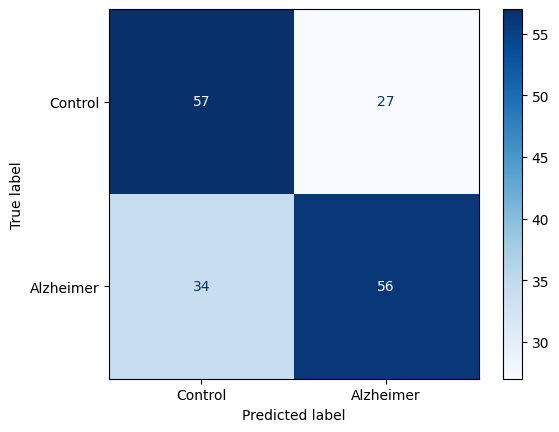

  [OK] Đã lưu: bilstm_confusion_matrix.pdf


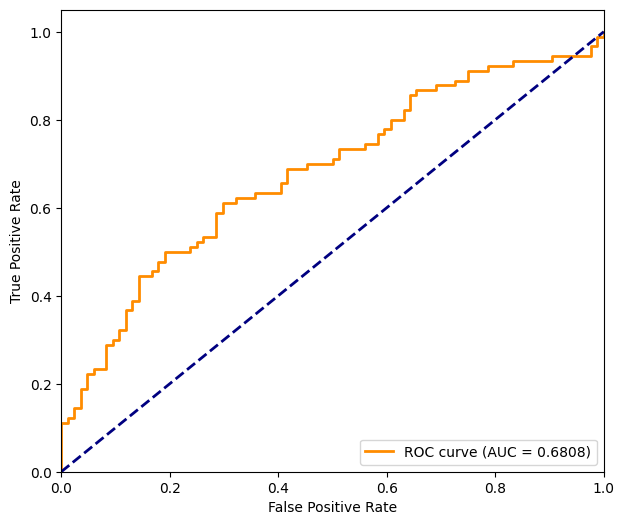

  [OK] Đã lưu: bilstm_roc_curve.pdf


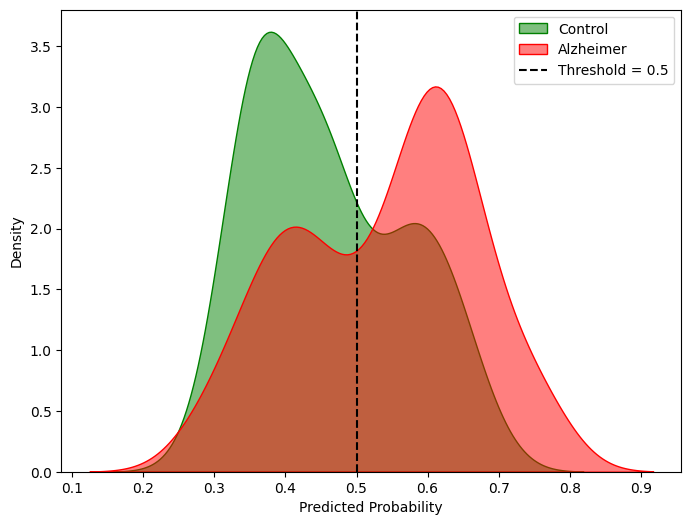

  [OK] Đã lưu: bilstm_risk_score_distribution.pdf
  [OK] Đã lưu dự đoán chi tiết: /content/our_result/test_predictions_detail.csv
  [OK] Đã lưu tóm tắt: /content/our_result/summary.txt

████████████████████████████████████████████████████████████
  PIPELINE HOÀN TẤT!
  AUC-ROC cuối cùng : 0.6808
  F1-Score cuối cùng: 0.6474
  Kết quả lưu tại   : /content/our_result/
████████████████████████████████████████████████████████████



In [ ]:

if __name__ == "__main__":
    train_df = pd.read_csv(CFG["train_file"], sep=r'\s+')
    test_df  = pd.read_csv(CFG["test_file"],  sep=r'\s+')

    print(f"Train: {train_df.shape[0]} samples × {train_df.shape[1]} columns")
    print(f"Test : {test_df.shape[0]} samples × {test_df.shape[1]} columns")


    snp_columns = train_df.columns[1:-1].tolist()
    snp_num     = len(snp_columns)
    print(f"SNP features: {snp_num}")

    train_label_counts = train_df.iloc[:, -1].value_counts().sort_index()
    test_label_counts  = test_df.iloc[:, -1].value_counts().sort_index()
    print(f"  [OK] Train label: NC={train_label_counts.get(0,0)}, "
          f"AD={train_label_counts.get(1,0)}")
    print(f"  [OK] Test  label: NC={test_label_counts.get(0,0)}, "
          f"AD={test_label_counts.get(1,0)}")

    X_train_val = train_df.iloc[:, 1:-1].values.astype('float32')
    y_train_val = train_df.iloc[:, -1].values.astype('float32')
    X_test      = test_df.iloc[:, 1:-1].values.astype('float32')
    y_test      = test_df.iloc[:, -1].values.astype('float32')

    unique_vals = np.unique(X_train_val)
    print(f"{unique_vals}")
    if any(v not in [0, 1, 2] for v in unique_vals):
        print(f"[WARN] - Found Value Out Of Range : {v}")

    # Biological Mapping
    mask_indices, block_ids_by_chr, total_blocks, chr_names = \
        create_biological_mapping(
            snp_columns=snp_columns,
            variant_meta_path=CFG["meta_file"],
            snps_per_block=CFG["snps_per_block"]
        )


    # checkpoint
    os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
    os.makedirs(CFG["output_dir"], exist_ok=True)

    test_predictions = np.zeros((X_test.shape[0], CFG["n_folds"]))

    fold_val_aucs = []

    kfold = StratifiedKFold(
        n_splits=CFG["n_folds"],
        shuffle=True,
        random_state=CFG["seed"]
    )

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_val, y_train_val)):
        print(f"\n  ┌── FOLD {fold+1}/{CFG['n_folds']} "
              f"(Train={len(train_idx)}, Val={len(val_idx)}) ──")

        X_tr, y_tr = X_train_val[train_idx], y_train_val[train_idx]
        X_va, y_va = X_train_val[val_idx],   y_train_val[val_idx]

        n_total  = len(y_tr)
        n_pos    = np.sum(y_tr)
        n_neg    = n_total - n_pos
        pos_weight = n_total / (2.0 * n_pos) if n_pos > 0 else 1.0
        neg_weight = n_total / (2.0 * n_neg) if n_neg > 0 else 1.0
        class_weight = {0: neg_weight, 1: pos_weight}
        print(f"  │  Class weights: {{0: {neg_weight:.3f}, 1: {pos_weight:.3f}}}")


        tf.random.set_seed(CFG["seed"] + fold)
        model = build_bilstm_model(
            snp_num=snp_num,
            block_num=total_blocks,
            mask_indices=mask_indices,
            block_ids_by_chr=block_ids_by_chr,
            cfg=CFG
        )

        if fold == 0:
            model.summary(print_fn=lambda x: print(f"  │  {x}"))
            print()

        chkpt_path = os.path.join(CFG["checkpoint_dir"], f"best_fold_{fold}.weights.h5")
        cbs = [
            callbacks.ModelCheckpoint(
                chkpt_path,
                save_weights_only=True,
                save_best_only=True,
                monitor='val_auc',
                mode='max',
                verbose=0
            ),
            callbacks.EarlyStopping(
                monitor='val_auc',
                patience=CFG["patience"],
                mode='max',
                restore_best_weights=True,
                verbose=0
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_auc',
                factor=0.9,
                patience=2,
                mode='max',
                min_lr=1e-6,
                verbose=0
            )
        ]

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            batch_size=CFG["batch_size"],
            epochs=CFG["max_epochs"],
            class_weight=class_weight,
            callbacks=cbs,
            verbose=0
        )

        best_val_auc = max(history.history['val_auc'])
        fold_val_aucs.append(best_val_auc)
        print(f"  │  Best val_auc = {best_val_auc:.4f} "
              f"(epoch {np.argmax(history.history['val_auc'])+1}/"
              f"{len(history.history['val_auc'])})")

        # Test on test set
        model.load_weights(chkpt_path)
        fold_preds = model.predict(X_test, batch_size=CFG["batch_size"], verbose=0)
        test_predictions[:, fold] = fold_preds.flatten()
        print(f"  └── Fold {fold+1} hoàn tất. "
              f"Test pred range: [{fold_preds.min():.3f}, {fold_preds.max():.3f}]")

        keras.backend.clear_session()


    print(f"  Val AUC: {[f'{a:.4f}' for a in fold_val_aucs]}")
    print(f"  Val AUC mean: {np.mean(fold_val_aucs):.4f} "
          f"± {np.std(fold_val_aucs):.4f}")

    # Ensemble Averaging
    final_probs = np.mean(test_predictions, axis=1)
    print(f"  Ensemble prob range: [{final_probs.min():.4f}, {final_probs.max():.4f}]")

    # Plots
    metrics, final_preds, opt_threshold = evaluate_and_plot(
        y_true=y_test,
        y_probs=final_probs,
        threshold=CFG["threshold"],
        output_dir=CFG["output_dir"]
    )

    result_df = pd.DataFrame({
        'True_Label'       : y_test.astype(int),
        'Pred_Probability' : np.round(final_probs, 6),
        'Pred_Class_0.5'   : final_preds,
        'Pred_Class_Youden': (final_probs >= opt_threshold).astype(int),
        **{f'Fold_{i+1}_Prob': np.round(test_predictions[:, i], 6)
           for i in range(CFG["n_folds"])}
    })
    csv_path = os.path.join(CFG["output_dir"], "test_predictions_detail.csv")
    result_df.to_csv(csv_path, index=False)
    print(f"  [OK] Đã lưu dự đoán chi tiết: {csv_path}")

    summary_lines = [
        f"snps_per_block={CFG['snps_per_block']}, "
        f"lstm_units={CFG['lstm_units']}, "
        f"dropout={CFG['dropout_rate']}, "
        f"l2={CFG['l2_lambda']}\n",
        f"{X_train_val.shape[0]} train, {X_test.shape[0]} test, "
        f"{snp_num} SNPs, {total_blocks} Blocks, {len(chr_names)} CHR\n\n",
        "--- Cross-Validation (10-Fold) ---\n",
        *[f"  Fold {i+1}: val_auc = {a:.4f}\n"
          for i, a in enumerate(fold_val_aucs)],
        f" {np.mean(fold_val_aucs):.4f} ± {np.std(fold_val_aucs):.4f}\n\n",
        *[f"  {k}: {v:.4f}\n" for k, v in metrics.items()],
    ]
    summary_path = os.path.join(CFG["output_dir"], "summary.txt")
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.writelines(summary_lines)
    print(f"  [OK] Đã lưu tóm tắt: {summary_path}")

    print("\n" + "█"*60)
    print(f"AUC-ROC: {metrics['AUC-ROC']:.4f}")
    print(f"F1-Score: {metrics['F1-Score']:.4f}")
    print(f"Kết quả : {CFG['output_dir']}/")
    print("█"*60 + "\n")